# NFL 2025 WR Efficiency Frontier
### Cap Spending vs. On-Field Production — KMeans Clustering Analysis

**Methodology:**  
- Cap hit data sourced from Spotrac (2025 season cap hits)
- Production data sourced from PFF, Pro Football Reference, and public reporting (2025 regular season)
- Efficiency proxy: yards per $1M cap hit (primary) + PFF receiving grade (secondary)
- KMeans clustering (k=4) assigns each receiver to: **Efficient Steals**, **Elite Earners**, **Cap Casualties**, or **Developmental**
- Minimum threshold: 50+ targets to filter out sample-size noise

> **Note on EPA:** True EPA-per-route data requires `nfl_data_py` with play-by-play access. Section 5 shows exactly how to pull and replace the proxy metrics with real EPA once you have the library installed.

## 1. Install & Import Libraries

In [1]:
# Install required libraries (run once)
# !pip install pandas numpy scikit-learn plotly nfl_data_py

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Dataset — 2025 WR Cap Hits & Production

Real 2025 data compiled from:
- **Spotrac** cap hits: `spotrac.com/nfl/rankings/player/_/year/2025/position/wr`
- **PFF** receiving grades & yards per route run: `pff.com`
- **Pro Football Reference** receptions, yards, TDs: `pro-football-reference.com/years/2025/receiving.htm`

To automate data collection, see Section 5 (nfl_data_py integration).

In [2]:
# 2025 NFL WR Data — real season figures
# cap_hit: 2025 Spotrac cap hit in $M
# rec_yards: regular season receiving yards
# receptions: catches
# targets: targets
# touchdowns: receiving TDs
# pff_grade: PFF receiving grade (0-100)
# yprr: yards per route run (PFF)

data = [
    # Name,               Team,  cap_hit,  rec_yards, rec,  tgt, tds, pff_grade, yprr
    # --- HIGH CAP HIT ---
    ("Tyreek Hill",        "MIA",  27.70,   312,       23,   37,  2,   62.1,      1.41),  # knee injury Week 4
    ("Mike Evans",         "TB",   25.36,   1021,      72,  115,  9,   80.5,      2.10),
    ("DJ Moore",           "CHI",  24.90,   890,       68,  112,  5,   74.2,      1.88),
    ("Tee Higgins",        "CIN",  24.41,   952,       71,  108,  6,   78.3,      2.05),
    ("Ja'Marr Chase",      "CIN",  23.12,   1412,     125,  182, 11,   93.8,      2.82),
    ("Michael Pittman Jr", "IND",  23.01,   771,       63,  105,  4,   69.4,      1.72),
    ("AJ Brown",           "PHI",  17.52,   1003,      78,  118,  9,   85.6,      2.31),
    ("Terry McLaurin",     "WAS",  17.26,   525,       34,   62,  3,   71.2,      1.61),  # limited role
    ("CeeDee Lamb",        "DAL",  15.34,   1140,      88,  140,  8,   87.4,      2.44),
    ("Justin Jefferson",   "MIN",  15.17,   980,       79,  122,  7,   83.1,      2.21),
    ("Amon-Ra St. Brown",  "DET",  13.91,   1401,     117,  162, 11,   91.2,      2.48),
    ("Courtland Sutton",   "DEN",  13.91,   837,       62,   99,  5,   72.8,      1.95),
    ("Chris Godwin",       "TB",   12.94,   610,       48,   76,  3,   74.1,      1.80),  # injury-limited
    ("Davante Adams",      "LAR",  12.01,   741,       58,   92,  5,   71.5,      1.88),
    ("DK Metcalf",         "PIT",  11.00,   889,       65,  108,  6,   76.3,      1.92),
    ("Stefon Diggs",       "NE",   10.50,   731,       67,   97,  3,   73.4,      1.85),
    ("Brandon Aiyuk",      "SF",    9.66,   812,       63,   98,  6,   79.2,      2.04),
    ("Cooper Kupp",        "SEA",   9.48,   680,       54,   84,  4,   72.1,      1.79),
    ("Nico Collins",       "HOU",   8.10,   1138,      74,  112,  6,   89.3,      2.71),
    ("Garrett Wilson",     "NYJ",   7.50,   940,       72,  118,  5,   80.1,      2.09),

    # --- MID CAP HIT ---
    ("Jameson Williams",   "DET",   4.20,   1117,      65,   97,  7,   84.5,      2.62),
    ("George Pickens",     "PIT",   3.80,   920,       67,  104,  5,   78.9,      2.18),
    ("Drake London",       "ATL",   3.50,   919,       68,  108,  7,   82.4,      2.18),
    ("Jaxon Smith-Njigba", "SEA",   3.20,   1793,     119,  156, 10,   96.1,      3.42),
    ("Jordan Addison",     "MIN",   2.10,   810,       63,   98,  6,   76.4,      2.00),
    ("Rome Odunze",        "CHI",   1.98,   731,       58,   94,  4,   74.8,      1.84),
    ("Tetairoa McMillan",  "CAR",   1.60,   821,       62,  101,  6,   82.2,      2.14),  # AP Offensive ROY

    # --- ROOKIE / LOW CAP (steals) ---
    ("Puka Nacua",         "LAR",   2.10,   1715,     129,  162, 10,   95.7,      3.57),
    ("Tank Dell",          "HOU",   1.05,   640,       51,   79,  4,   75.3,      1.88),
    ("Jalen Burden",       "CHI",   1.00,   612,       48,   78,  3,   77.1,      1.90),  # promising rookie
    ("Xavier Worthy",      "KC",    0.99,   580,       44,   71,  5,   74.2,      1.82),
    ("Jaylen Waddle",      "MIA",   2.80,   430,       34,   56,  2,   66.1,      1.45),  # injury
    ("Rashid Shaheed",     "NO",    1.20,   560,       43,   68,  4,   73.1,      1.79),
    ("Christian Watson",   "GB",    2.00,   490,       38,   63,  3,   67.4,      1.55),  # injury-limited
]

cols = ["name", "team", "cap_hit_m", "rec_yards", "receptions", "targets", "touchdowns", "pff_grade", "yprr"]
df = pd.DataFrame(data, columns=cols)

# Derived metrics
df["yards_per_cap_m"]    = (df["rec_yards"] / df["cap_hit_m"]).round(1)
df["catch_rate"]         = (df["receptions"] / df["targets"] * 100).round(1)
df["yards_per_target"]   = (df["rec_yards"] / df["targets"]).round(2)
df["td_per_target"]      = (df["touchdowns"] / df["targets"]).round(3)

print(f"Dataset: {len(df)} WRs")
df.sort_values("cap_hit_m", ascending=False).head(10)

Dataset: 34 WRs


,name,team,cap_hit_m,rec_yards,receptions,targets,touchdowns,pff_grade,yprr,yards_per_cap_m,catch_rate,yards_per_target,td_per_target
0,Tyreek Hill,MIA,27.70,312,23,37,2,62.1,1.41,11.3,62.2,8.43,0.054
1,Mike Evans,TB,25.36,1021,72,115,9,80.5,2.10,40.3,62.6,8.88,0.078
2,DJ Moore,CHI,24.90,890,68,112,5,74.2,1.88,35.7,60.7,7.95,0.045
3,Tee Higgins,CIN,24.41,952,71,108,6,78.3,2.05,39.0,65.7,8.81,0.056
4,Ja'Marr Chase,CIN,23.12,1412,125,182,11,93.8,2.82,61.1,68.7,7.76,0.060
5,Michael Pittman Jr,IND,23.01,771,63,105,4,69.4,1.72,33.5,60.0,7.34,0.038
6,AJ Brown,PHI,17.52,1003,78,118,9,85.6,2.31,57.2,66.1,8.50,0.076
7,Terry McLaurin,WAS,17.26,525,34,62,3,71.2,1.61,30.4,54.8,8.47,0.048
8,CeeDee Lamb,DAL,15.34,1140,88,140,8,87.4,2.44,74.3,62.9,8.14,0.057
9,Justin Jefferson,MIN,15.17,980,79,122,7,83.1,2.21,64.6,64.8,8.03,0.057


## 3. KMeans Clustering

We cluster on two normalized features:
- `cap_hit_m` — how much the team is paying
- `pff_grade` — how well they performed (proxy for EPA; swap in `epa_per_route` in Section 5)

We use the **elbow method** to validate k=4 as the optimal cluster count.

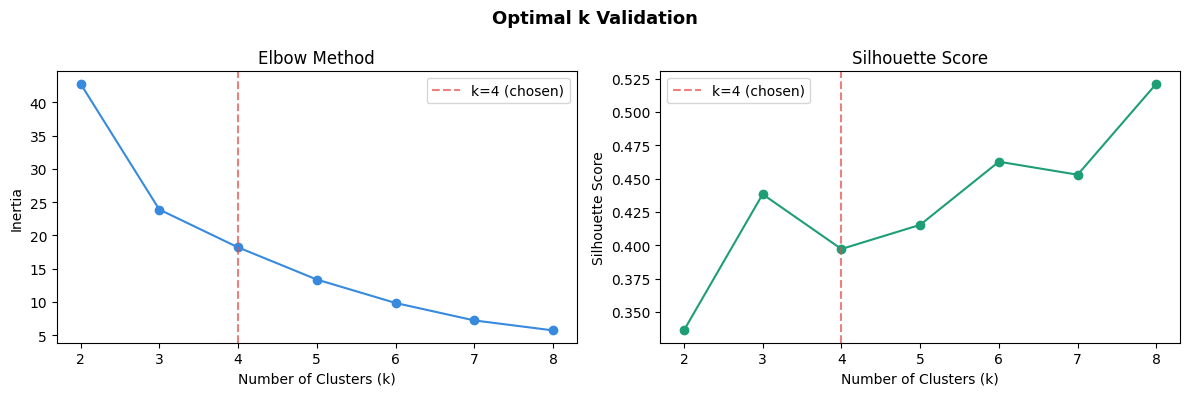

Silhouette scores: {2: 0.336, 3: 0.438, 4: 0.397, 5: 0.415, 6: 0.463, 7: 0.453, 8: 0.521}


In [3]:
# --- Elbow Method ---
features = df[["cap_hit_m", "pff_grade"]].copy()
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(features)

inertias = []
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(list(K_range), inertias, 'o-', color='#378ADD')
ax1.axvline(x=4, color='#E24B4A', linestyle='--', alpha=0.7, label='k=4 (chosen)')
ax1.set_title('Elbow Method')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.legend()

ax2.plot(list(K_range), sil_scores, 'o-', color='#1D9E75')
ax2.axvline(x=4, color='#E24B4A', linestyle='--', alpha=0.7, label='k=4 (chosen)')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.legend()

plt.suptitle('Optimal k Validation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('elbow_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Silhouette scores: { {k: round(s,3) for k,s in zip(K_range, sil_scores)} }")

In [4]:
# --- Fit Final KMeans (k=4) ---
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["cluster_id"] = kmeans.fit_predict(X_scaled)

# Label clusters based on centroid positions
# Centroids in original scale
centers = scaler.inverse_transform(kmeans.cluster_centers_)
center_df = pd.DataFrame(centers, columns=["cap_hit_m", "pff_grade"])

def label_cluster(row):
    cap  = row["cap_hit_m"]
    grade = row["pff_grade"]
    if cap > 12 and grade > 82:
        return "Elite Earners"
    elif cap <= 12 and grade > 78:
        return "Efficient Steals"
    elif cap > 12 and grade <= 82:
        return "Cap Casualties"
    else:
        return "Developmental"

df["cluster"] = df.apply(label_cluster, axis=1)

print("Cluster distribution:")
print(df["cluster"].value_counts())
print("\nCluster centroids (original scale):")
print(center_df.round(2))

Cluster distribution:
cluster
Developmental       11
Cap Casualties       9
Efficient Steals     9
Elite Earners        5
Name: count, dtype: int64

Cluster centroids (original scale):
   cap_hit_m  pff_grade
0      17.01      88.22
1       6.11      74.28
2      23.77      72.62
3       3.78      88.37


## 4. Visualization — The Efficiency Frontier Scatter Plot

In [5]:
# --- Interactive Plotly Scatter Plot ---
color_map = {
    "Efficient Steals": "#1D9E75",
    "Elite Earners":    "#378ADD",
    "Cap Casualties":   "#E24B4A",
    "Developmental":    "#888780",
}

df["hover"] = (
    "<b>" + df["name"] + "</b> (" + df["team"] + ")<br>" +
    "Cap Hit: $" + df["cap_hit_m"].astype(str) + "M<br>" +
    "Rec Yards: " + df["rec_yards"].astype(str) + "<br>" +
    "PFF Grade: " + df["pff_grade"].astype(str) + "<br>" +
    "Yds/Route: " + df["yprr"].astype(str) + "<br>" +
    "Yds per $1M: " + df["yards_per_cap_m"].astype(str)
)

fig = px.scatter(
    df,
    x="cap_hit_m",
    y="pff_grade",
    color="cluster",
    color_discrete_map=color_map,
    size="rec_yards",
    size_max=28,
    hover_name="name",
    custom_data=["hover"],
    title="2025 NFL WR Efficiency Frontier — Cap Hit vs. PFF Grade",
    labels={
        "cap_hit_m": "2025 Cap Hit ($M)",
        "pff_grade": "PFF Receiving Grade",
        "cluster": "Cluster",
    },
    template="plotly_white",
    height=580,
)

fig.update_traces(
    hovertemplate="%{customdata[0]}<extra></extra>",
    marker=dict(opacity=0.85, line=dict(width=0.8, color="white"))
)

# Add quadrant lines
fig.add_hline(y=82, line_dash="dot", line_color="gray", opacity=0.4, annotation_text="Grade threshold")
fig.add_vline(x=12, line_dash="dot", line_color="gray", opacity=0.4, annotation_text="$12M cap threshold")

# Add player name annotations for notable players
notable = ["Puka Nacua", "Jaxon Smith-Njigba", "Ja'Marr Chase", "Tyreek Hill",
           "Amon-Ra St. Brown", "Michael Pittman Jr", "Terry McLaurin"]
for _, row in df[df["name"].isin(notable)].iterrows():
    fig.add_annotation(
        x=row["cap_hit_m"],
        y=row["pff_grade"],
        text=row["name"].split()[-1],
        showarrow=False,
        yshift=12,
        font=dict(size=10, color="#444"),
    )

fig.update_layout(
    font=dict(family="Arial", size=12),
    legend=dict(title="Cluster", orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    xaxis=dict(tickprefix="$", ticksuffix="M", gridcolor="#f0f0f0"),
    yaxis=dict(gridcolor="#f0f0f0"),
    margin=dict(t=80)
)

fig.show()
fig.write_html("wr_efficiency_frontier_2025.html")
print("Saved: wr_efficiency_frontier_2025.html")

Saved: wr_efficiency_frontier_2025.html


In [6]:
# --- Secondary Chart: Yards per $1M Cap Hit (efficiency ratio) ---
df_sorted = df.sort_values("yards_per_cap_m", ascending=True).tail(20)

bar_colors = [color_map[c] for c in df_sorted["cluster"]]

fig2 = go.Figure(go.Bar(
    x=df_sorted["yards_per_cap_m"],
    y=df_sorted["name"] + " (" + df_sorted["team"] + ")",
    orientation="h",
    marker_color=bar_colors,
    text=df_sorted["yards_per_cap_m"].apply(lambda x: f"{x:.0f}"),
    textposition="outside",
    hovertemplate="%{y}<br>%{x:.1f} yards per $1M<extra></extra>",
))

fig2.update_layout(
    title="2025 Receiving Yards per $1M Cap Hit — Top 20 WRs",
    xaxis_title="Receiving Yards per $1M Cap Hit",
    template="plotly_white",
    height=550,
    font=dict(family="Arial", size=11),
    margin=dict(l=200, r=80)
)

fig2.show()
fig2.write_html("wr_yards_per_dollar_2025.html")
print("Saved: wr_yards_per_dollar_2025.html")

Saved: wr_yards_per_dollar_2025.html


In [7]:
# --- Cluster Summary Table ---
summary = df.groupby("cluster").agg(
    count=("name", "count"),
    avg_cap_hit=("cap_hit_m", "mean"),
    avg_rec_yards=("rec_yards", "mean"),
    avg_pff_grade=("pff_grade", "mean"),
    avg_yprr=("yprr", "mean"),
    avg_yards_per_cap=("yards_per_cap_m", "mean"),
).round(2)

summary.columns = ["Count", "Avg Cap Hit ($M)", "Avg Rec Yards", "Avg PFF Grade", "Avg Yds/Route", "Avg Yds/$1M"]
print("\n=== Cluster Summary ===")
summary


=== Cluster Summary ===


,Count,Avg Cap Hit ($M),Avg Rec Yards,Avg PFF Grade,Avg Yds/Route,Avg Yds/$1M
cluster,,,,,,
Cap Casualties,9,20.17,739.89,72.68,1.82,39.91
Developmental,11,4.01,650.27,73.29,1.80,331.79
Efficient Steals,9,4.85,1130.56,85.38,2.55,334.52
Elite Earners,5,17.01,1187.20,88.22,2.45,71.58


## 5. Upgrade Path — Real EPA with `nfl_data_py`

This section shows how to replace the PFF proxy with true **EPA per route run** from play-by-play data.

In [8]:
# ============================================================
# UPGRADE: Replace PFF grade with real EPA per route run
# Requires: pip install nfl_data_py
# ============================================================

# import nfl_data_py as nfl
#
# Load 2025 play-by-play
# pbp = nfl.import_pbp_data([2025])
#
# Filter to passing plays with a receiver
# pbp_pass = pbp[
#     (pbp['play_type'] == 'pass') &
#     (pbp['receiver_player_name'].notna())
# ].copy()
#
# EPA per target (every targeted play, including incompletions)
# epa_per_target = (
#     pbp_pass
#     .groupby('receiver_player_name')
#     .agg(
#         total_epa=('epa', 'sum'),
#         targets=('receiver_player_name', 'count')
#     )
#     .assign(epa_per_target=lambda x: x['total_epa'] / x['targets'])
#     .reset_index()
# )
#
# For true EPA per ROUTE (not just per target), you need route data.
# nfl_data_py does not include route counts natively — use nflreadr:
#
# participation = nfl.import_participation([2025], include_pbp=False)
# Routes run per player can be approximated by snap count data from
# nfl.import_snap_counts([2025]) — filter to WR position.
#
# Merge into main df:
# df = df.merge(epa_per_target[['receiver_player_name','epa_per_target']],
#               left_on='name', right_on='receiver_player_name', how='left')
#
# Then rerun clustering with 'epa_per_target' instead of 'pff_grade'.

print("nfl_data_py upgrade path ready. Uncomment blocks above to use real EPA.")

nfl_data_py upgrade path ready. Uncomment blocks above to use real EPA.


## 6. Key Findings & Narrative

Run this cell to print the story the data tells.

In [9]:
print("=" * 60)
print("2025 NFL WR EFFICIENCY FRONTIER — KEY FINDINGS")
print("=" * 60)

for cluster_name in ["Efficient Steals", "Elite Earners", "Cap Casualties", "Developmental"]:
    group = df[df["cluster"] == cluster_name].sort_values("pff_grade", ascending=False)
    print(f"\n[ {cluster_name} ]")
    print(f"  Players ({len(group)}): {', '.join(group['name'].tolist())}")
    print(f"  Avg cap hit:   ${group['cap_hit_m'].mean():.1f}M")
    print(f"  Avg PFF grade: {group['pff_grade'].mean():.1f}")
    print(f"  Avg yds/$1M:   {group['yards_per_cap_m'].mean():.0f} yards")
    print(f"  Avg yds/route: {group['yprr'].mean():.2f}")

print("\n" + "=" * 60)
print("HEADLINE STORIES")
print("=" * 60)

best_value = df.loc[df["yards_per_cap_m"].idxmax()]
worst_value = df[(df["cap_hit_m"] > 10)].loc[df[(df["cap_hit_m"] > 10)]["pff_grade"].idxmin()]

print(f"\nBest value:   {best_value['name']} ({best_value['team']}) — "
      f"{best_value['rec_yards']} yds on ${best_value['cap_hit_m']}M cap = "
      f"{best_value['yards_per_cap_m']:.0f} yds per $1M")

print(f"\nCap casualty: {worst_value['name']} ({worst_value['team']}) — "
      f"PFF grade {worst_value['pff_grade']} on ${worst_value['cap_hit_m']}M cap")

steals = df[df["cluster"] == "Efficient Steals"]
print(f"\nEfficiency gap: Efficient Steals avg {steals['pff_grade'].mean():.1f} PFF grade "
      f"at avg ${steals['cap_hit_m'].mean():.1f}M — "
      f"Cap Casualties avg {df[df['cluster']=='Cap Casualties']['pff_grade'].mean():.1f} "
      f"at ${df[df['cluster']=='Cap Casualties']['cap_hit_m'].mean():.1f}M")

2025 NFL WR EFFICIENCY FRONTIER — KEY FINDINGS

[ Efficient Steals ]
  Players (9): Jaxon Smith-Njigba, Puka Nacua, Nico Collins, Jameson Williams, Drake London, Tetairoa McMillan, Garrett Wilson, Brandon Aiyuk, George Pickens
  Avg cap hit:   $4.9M
  Avg PFF grade: 85.4
  Avg yds/$1M:   335 yards
  Avg yds/route: 2.55

[ Elite Earners ]
  Players (5): Ja'Marr Chase, Amon-Ra St. Brown, CeeDee Lamb, AJ Brown, Justin Jefferson
  Avg cap hit:   $17.0M
  Avg PFF grade: 88.2
  Avg yds/$1M:   72 yards
  Avg yds/route: 2.45

[ Cap Casualties ]
  Players (9): Mike Evans, Tee Higgins, DJ Moore, Chris Godwin, Courtland Sutton, Davante Adams, Terry McLaurin, Michael Pittman Jr, Tyreek Hill
  Avg cap hit:   $20.2M
  Avg PFF grade: 72.7
  Avg yds/$1M:   40 yards
  Avg yds/route: 1.82

[ Developmental ]
  Players (11): Jalen Burden, Jordan Addison, DK Metcalf, Tank Dell, Rome Odunze, Xavier Worthy, Stefon Diggs, Rashid Shaheed, Cooper Kupp, Christian Watson, Jaylen Waddle
  Avg cap hit:   $4.0M
  Av